# Fashion-MNIST Clothing Classifier - Multi-Layer Perceptron (MLP)

## Project Overview

This notebook demonstrates how to build and train a Multi-Layer Perceptron (MLP) to classify clothing items from the Fashion-MNIST dataset using PyTorch.

### Learning Objectives:
- Feature scaling and normalization techniques
- Weight initialization strategies
- Designing and training MLPs with multiple hidden layers
- Understanding the impact of different initialization methods
- Complete ML workflow from problem definition to deployment

### Dataset:
- **Fashion-MNIST**: 28×28 grayscale images of clothing items
- **10 classes**: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
- **Input**: 784 features (flattened 28×28 image)
- **Output**: 10 classes

---


## Part 1: Problem Definition

### Understanding the Task

**Problem Type**: Multi-class classification
- **Input**: 28×28 grayscale images of clothing items
- **Output**: Class label (0-9, representing 10 clothing categories)
- **Goal**: Predict the clothing category shown in the image with high accuracy

### Fashion-MNIST Classes:
0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

### Key Considerations:
1. **More Complex than MNIST**: Clothing items have more variation than digits
2. **Feature Scaling**: Critical for neural network training
3. **Weight Initialization**: Proper initialization crucial for deep networks
4. **Multiple Hidden Layers**: Need sufficient capacity to learn complex patterns

### Success Criteria:
- Training accuracy > 85%
- Validation accuracy > 85%
- Generalization to unseen test data


## Part 2: Data Collection

### Fashion-MNIST Dataset

The Fashion-MNIST dataset is a more challenging alternative to MNIST:
- **60,000 training images**
- **10,000 test images**
- **10 classes** (clothing items)
- **28×28 pixels** per image
- **Grayscale** (single channel)

PyTorch provides easy access to Fashion-MNIST through `torchvision.datasets`.


In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, List
import time

# Custom implementations to avoid sklearn dependency issues
def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, labels: List[int] = None) -> np.ndarray:
    """
    Compute confusion matrix without sklearn dependency.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        labels: List of all possible labels (if None, inferred from data)
        
    Returns:
        Confusion matrix as numpy array
    """
    if labels is None:
        labels = sorted(list(set(y_true) | set(y_pred)))
    
    n_classes = len(labels)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    label_to_idx = {label: idx for idx, label in enumerate(labels)}
    
    for true, pred in zip(y_true, y_pred):
        true_idx = label_to_idx[true]
        pred_idx = label_to_idx[pred]
        cm[true_idx, pred_idx] += 1
    
    return cm


def classification_report(y_true: np.ndarray, y_pred: np.ndarray, 
                         target_names: List[str] = None, 
                         output_dict: bool = False) -> Dict:
    """
    Generate classification report without sklearn dependency.
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        target_names: Names for each class
        output_dict: If True, return as dictionary
        
    Returns:
        Classification report as dictionary
    """
    labels = sorted(list(set(y_true) | set(y_pred)))
    n_classes = len(labels)
    
    if target_names is None:
        target_names = [str(label) for label in labels]
    
    # Calculate metrics for each class
    report = {}
    total_precision = 0
    total_recall = 0
    total_f1 = 0
    
    for i, label in enumerate(labels):
        tp = np.sum((y_true == label) & (y_pred == label))
        fp = np.sum((y_true != label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        support = np.sum(y_true == label)
        
        report[target_names[i]] = {
            'precision': precision,
            'recall': recall,
            'f1-score': f1,
            'support': support
        }
        
        total_precision += precision
        total_recall += recall
        total_f1 += f1
    
    # Calculate averages
    report['macro avg'] = {
        'precision': total_precision / n_classes,
        'recall': total_recall / n_classes,
        'f1-score': total_f1 / n_classes,
        'support': len(y_true)
    }
    
    # Weighted averages
    weighted_precision = sum(report[name]['precision'] * report[name]['support'] 
                            for name in target_names) / len(y_true)
    weighted_recall = sum(report[name]['recall'] * report[name]['support'] 
                         for name in target_names) / len(y_true)
    weighted_f1 = sum(report[name]['f1-score'] * report[name]['support'] 
                     for name in target_names) / len(y_true)
    
    report['weighted avg'] = {
        'precision': weighted_precision,
        'recall': weighted_recall,
        'f1-score': weighted_f1,
        'support': len(y_true)
    }
    
    # Accuracy
    accuracy = np.sum(y_true == y_pred) / len(y_true)
    report['accuracy'] = accuracy
    
    return report

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Fashion-MNIST class names
fashion_classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


Using device: cpu


## Part 3: Data Understanding

Let's explore the Fashion-MNIST dataset to understand its characteristics.


In [2]:
def explore_dataset(data_loader: DataLoader, dataset_name: str = "Dataset", class_names: List[str] = None) -> None:
    """
    Explore and visualize dataset characteristics.
    
    Args:
        data_loader: DataLoader to explore
        dataset_name: Name of the dataset for display
        class_names: List of class names
    """
    # Get a batch of data
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name} Exploration")
    print(f"{'='*60}")
    print(f"Batch size: {images.shape[0]}")
    print(f"Image shape: {images.shape}")
    print(f"Image pixel range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Labels shape: {labels.shape}")
    print(f"Labels range: [{labels.min()}, {labels.max()}]")
    print(f"Number of classes: {len(torch.unique(labels))}")
    
    # Visualize some samples
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f'{dataset_name} - Sample Images', fontsize=16)
    
    for idx in range(10):
        row = idx // 5
        col = idx % 5
        img = images[idx].squeeze()
        label_idx = labels[idx].item()
        label_name = class_names[label_idx] if class_names else str(label_idx)
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'{label_name} ({label_idx})', fontsize=10)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Class distribution
    all_labels = []
    for _, labels_batch in data_loader:
        all_labels.extend(labels_batch.numpy())
    
    unique, counts = np.unique(all_labels, return_counts=True)
    print(f"\nClass Distribution:")
    for cls, count in zip(unique, counts):
        cls_name = class_names[cls] if class_names else str(cls)
        print(f"  {cls_name} ({cls}): {count} samples ({count/len(all_labels)*100:.1f}%)")
    
    # Plot class distribution
    plt.figure(figsize=(12, 5))
    plt.bar(range(len(unique)), counts, color='steelblue', alpha=0.7)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.title(f'{dataset_name} - Class Distribution', fontsize=14)
    plt.xticks(range(len(unique)), [class_names[i] if class_names else str(i) for i in unique], rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## Part 4: Data Preprocessing - Feature Scaling

### Why Feature Scaling Matters:

1. **Gradient Stability**: Scaled features lead to more stable gradients
2. **Faster Convergence**: Normalized inputs help optimization converge faster
3. **Weight Initialization**: Works better with normalized inputs
4. **Prevents Vanishing/Exploding Gradients**: Especially important for deep networks

### Scaling Techniques:

1. **Min-Max Scaling**: Scale to [0, 1] range (handled by `ToTensor()`)
2. **Standard Normalization**: Zero mean, unit variance (mean=0, std=1)
3. **Custom Normalization**: Using dataset-specific statistics

### Fashion-MNIST Statistics:
- Mean: ~0.286
- Std: ~0.353

We'll use standard normalization for better training.


Dataset Statistics (before normalization):
  Mean: 0.2860
  Std: 0.3205

Training batches: 750
Validation batches: 188
Test batches: 157

After normalization:
  Image pixel range: [-0.810, 2.023]
  Image mean: 0.0204
  Image std: 0.9995

Training Dataset Exploration
Batch size: 64
Image shape: torch.Size([64, 1, 28, 28])
Image pixel range: [-0.810, 2.023]
Labels shape: torch.Size([64])
Labels range: [0, 9]
Number of classes: 10


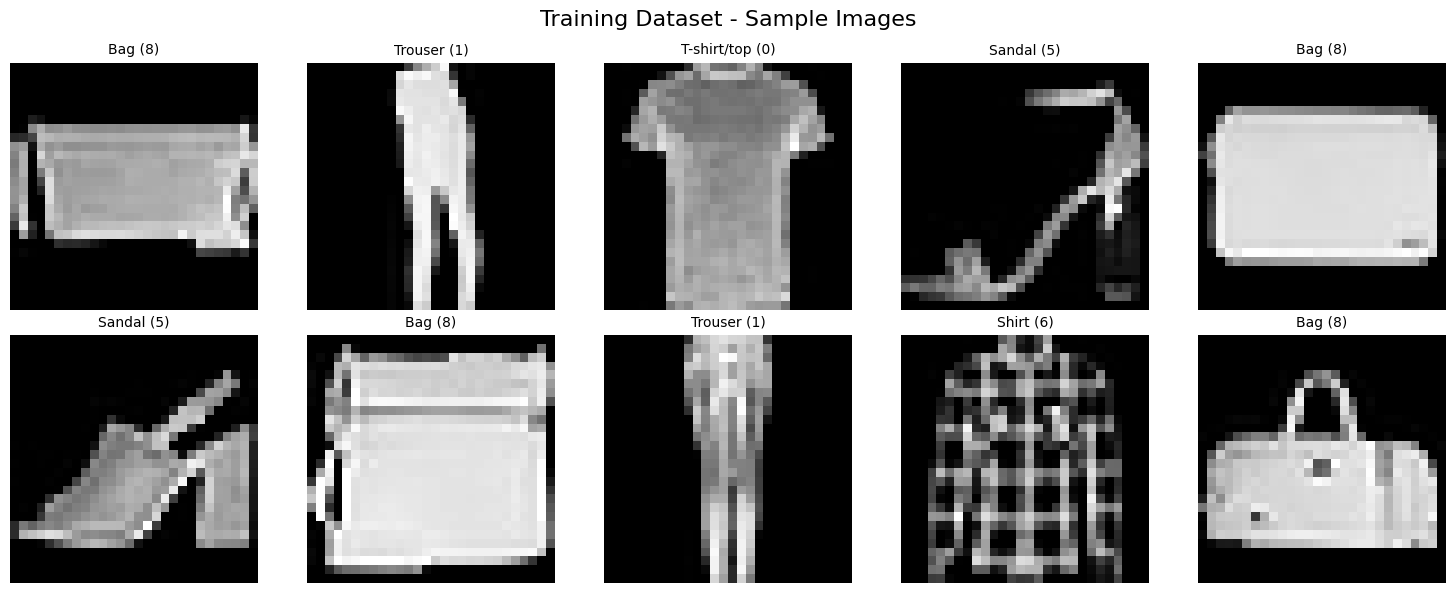


Class Distribution:
  T-shirt/top (0): 4732 samples (9.9%)
  Trouser (1): 4752 samples (9.9%)
  Pullover (2): 4825 samples (10.1%)
  Dress (3): 4852 samples (10.1%)
  Coat (4): 4807 samples (10.0%)
  Sandal (5): 4797 samples (10.0%)
  Shirt (6): 4788 samples (10.0%)
  Sneaker (7): 4866 samples (10.1%)
  Bag (8): 4805 samples (10.0%)
  Ankle boot (9): 4776 samples (10.0%)


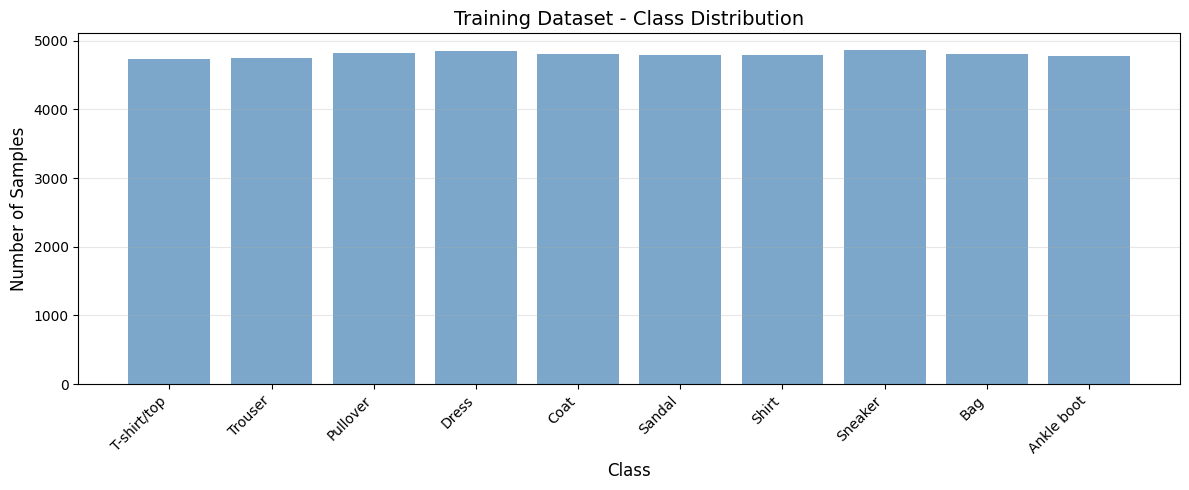

In [3]:
def calculate_dataset_statistics(data_loader: DataLoader) -> Dict[str, float]:
    """
    Calculate mean and std of the dataset for normalization.
    
    Args:
        data_loader: DataLoader to analyze
        
    Returns:
        Dictionary with mean and std values
    """
    mean = 0.0
    std = 0.0
    total_samples = 0
    
    for images, _ in data_loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_samples += batch_samples
    
    mean /= total_samples
    std /= total_samples
    
    return {'mean': mean.item(), 'std': std.item()}


def load_fashion_mnist_data(
    root: str = './data', 
    batch_size: int = 64,
    normalize: bool = True,
    custom_stats: Tuple[float, float] = None
) -> Tuple[DataLoader, DataLoader, DataLoader, Dict[str, float]]:
    """
    Load Fashion-MNIST dataset with optional normalization.
    
    Args:
        root: Root directory for storing the dataset
        batch_size: Number of samples per batch
        normalize: Whether to apply standard normalization
        custom_stats: Custom (mean, std) tuple for normalization
        
    Returns:
        Tuple of (train_loader, val_loader, test_loader, statistics)
    """
    # Base transformation: convert to tensor and scale to [0, 1]
    transform_list = [transforms.ToTensor()]
    
    # Add normalization if requested
    if normalize:
        if custom_stats is None:
            # Use Fashion-MNIST standard statistics
            # These are precomputed: mean=0.2860, std=0.3530
            transform_list.append(transforms.Normalize((0.2860,), (0.3530,)))
        else:
            transform_list.append(transforms.Normalize((custom_stats[0],), (custom_stats[1],)))
    
    transform = transforms.Compose(transform_list)
    
    # Load training dataset
    train_dataset = datasets.FashionMNIST(
        root=root,
        train=True,
        download=True,
        transform=transform
    )
    
    # Split training data into train and validation (80-20 split)
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(
        train_dataset, 
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    
    # Load test dataset
    test_dataset = datasets.FashionMNIST(
        root=root,
        train=False,
        download=True,
        transform=transform
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )
    
    # Calculate statistics (before normalization for reference)
    temp_transform = transforms.Compose([transforms.ToTensor()])
    temp_dataset = datasets.FashionMNIST(root=root, train=True, download=False, transform=temp_transform)
    temp_loader = DataLoader(temp_dataset, batch_size=batch_size, shuffle=False)
    stats = calculate_dataset_statistics(temp_loader)
    
    return train_loader, val_loader, test_loader, stats

# Load the data with normalization
train_loader, val_loader, test_loader, dataset_stats = load_fashion_mnist_data(
    batch_size=64, 
    normalize=True
)

print(f"Dataset Statistics (before normalization):")
print(f"  Mean: {dataset_stats['mean']:.4f}")
print(f"  Std: {dataset_stats['std']:.4f}")
print(f"\nTraining batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Verify normalization
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(f"\nAfter normalization:")
print(f"  Image pixel range: [{images.min():.3f}, {images.max():.3f}]")
print(f"  Image mean: {images.mean():.4f}")
print(f"  Image std: {images.std():.4f}")

# Explore the dataset
explore_dataset(train_loader, "Training Dataset", fashion_classes)


## Part 5: Cross-Validation

### Train-Validation-Test Split

We've split the data:
- **Training Set**: 48,000 samples (80% of 60,000) - Used to train the model
- **Validation Set**: 12,000 samples (20% of 60,000) - Used to tune hyperparameters
- **Test Set**: 10,000 samples - Used for final evaluation (never seen during training)

This split ensures we can properly evaluate model generalization.


## Part 6: Model Selection - Multiple Hidden Layers & Weight Initialization

### MLP Architecture Design

For Fashion-MNIST classification, we need:
1. **Multiple Hidden Layers**: More capacity to learn complex patterns
2. **Proper Weight Initialization**: Critical for training deep networks
3. **Sufficient Capacity**: Fashion items are more complex than digits

### Design Decisions:

#### 1. **Number of Hidden Layers**
- **Decision**: Use 4-5 hidden layers for sufficient capacity
- **Architecture**: 784 → 512 → 256 → 128 → 64 → 10

#### 2. **Weight Initialization Strategies**

**Why Weight Initialization Matters:**
- Poor initialization can lead to vanishing/exploding gradients
- Affects training speed and final performance
- Critical for deep networks

**Common Initialization Methods:**

1. **Xavier/Glorot Initialization** (for tanh/sigmoid):
   - `nn.init.xavier_uniform_()` or `nn.init.xavier_normal_()`
   - Good for tanh and sigmoid activations

2. **He Initialization** (for ReLU):
   - `nn.init.kaiming_uniform_()` or `nn.init.kaiming_normal_()`
   - Better for ReLU activations (recommended for our network)

3. **Default PyTorch Initialization**:
   - Uniform distribution: U(-1/√fan_in, 1/√fan_in)
   - Works but not optimal

4. **Zero Initialization** (BAD):
   - All weights = 0 leads to symmetry breaking issues

**Decision**: Use He initialization (Kaiming) for ReLU activations

#### 3. **Activation Functions**
- **ReLU**: Standard choice, works well with He initialization

#### 4. **Regularization**
- **Dropout**: 0.3-0.5 to prevent overfitting

### Architecture Summary:
```
Input (784) 
  → Hidden 1 (512) + ReLU + Dropout(0.3)
  → Hidden 2 (256) + ReLU + Dropout(0.3)
  → Hidden 3 (128) + ReLU + Dropout(0.3)
  → Hidden 4 (64) + ReLU + Dropout(0.3)
  → Output (10) [no activation]
```


In [4]:
class FashionMLP(nn.Module):
    """
    Multi-Layer Perceptron for Fashion-MNIST classification.
    
    Features:
    - Multiple hidden layers (4-5 layers)
    - Custom weight initialization
    - Dropout regularization
    
    Args:
        input_size: Number of input features (default: 784 for Fashion-MNIST)
        hidden_sizes: List of hidden layer sizes (default: [512, 256, 128, 64])
        num_classes: Number of output classes (default: 10)
        dropout_rate: Dropout probability (default: 0.3)
        init_method: Weight initialization method ('he', 'xavier', 'default')
    """
    
    def __init__(
        self, 
        input_size: int = 784,
        hidden_sizes: List[int] = None,
        num_classes: int = 10,
        dropout_rate: float = 0.3,
        init_method: str = 'he'
    ):
        super(FashionMLP, self).__init__()
        
        if hidden_sizes is None:
            hidden_sizes = [512, 256, 128, 64]
        
        # Build layers dynamically
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        
        prev_size = input_size
        
        # Hidden layers
        for hidden_size in hidden_sizes:
            self.layers.append(nn.Linear(prev_size, hidden_size))
            self.activations.append(nn.ReLU())
            self.dropouts.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        # Output layer (no activation - CrossEntropyLoss includes Softmax)
        self.output_layer = nn.Linear(prev_size, num_classes)
        
        # Initialize weights
        self._initialize_weights(init_method)
    
    def _initialize_weights(self, init_method: str) -> None:
        """
        Initialize weights using specified method.
        
        Args:
            init_method: Initialization method ('he', 'xavier', 'default')
        """
        for layer in self.layers:
            if init_method == 'he':
                # He initialization (Kaiming) - recommended for ReLU
                nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='relu')
                nn.init.constant_(layer.bias, 0)
            elif init_method == 'xavier':
                # Xavier/Glorot initialization - good for tanh/sigmoid
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)
            elif init_method == 'default':
                # PyTorch default initialization
                pass  # Already initialized by PyTorch
            else:
                raise ValueError(f"Unknown initialization method: {init_method}")
        
        # Initialize output layer (usually smaller scale)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.constant_(self.output_layer.bias, 0)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28) or (batch_size, 784)
            
        Returns:
            Output tensor of shape (batch_size, num_classes)
        """
        # Flatten the input if it's 2D (batch_size, 1, 28, 28)
        if x.dim() > 2:
            x = x.view(x.size(0), -1)  # Flatten to (batch_size, 784)
        
        # Pass through hidden layers
        for layer, activation, dropout in zip(self.layers, self.activations, self.dropouts):
            x = layer(x)
            x = activation(x)
            x = dropout(x)
        
        # Output layer
        x = self.output_layer(x)
        
        return x
    
    def count_parameters(self) -> int:
        """
        Count the number of trainable parameters in the model.
        
        Returns:
            Total number of parameters
        """
        return sum(p.numel() for p in self.parameters() if p.requires_grad)
    
    def get_weight_statistics(self) -> Dict:
        """
        Get statistics about weight initialization.
        
        Returns:
            Dictionary with weight statistics
        """
        stats = {}
        for i, layer in enumerate(self.layers):
            weights = layer.weight.data.cpu().numpy()
            stats[f'layer_{i}'] = {
                'mean': float(weights.mean()),
                'std': float(weights.std()),
                'min': float(weights.min()),
                'max': float(weights.max())
            }
        return stats

# Create model with He initialization
model = FashionMLP(
    input_size=784,
    hidden_sizes=[512, 256, 128, 64],
    num_classes=10,
    dropout_rate=0.3,
    init_method='he'
).to(device)

print("Model Architecture:")
print(model)
print(f"\nTotal Parameters: {model.count_parameters():,}")

# Display weight initialization statistics
print("\nWeight Initialization Statistics:")
weight_stats = model.get_weight_statistics()
for layer_name, stats in weight_stats.items():
    print(f"{layer_name}:")
    print(f"  Mean: {stats['mean']:.6f}, Std: {stats['std']:.6f}")
    print(f"  Range: [{stats['min']:.6f}, {stats['max']:.6f}]")

# Test forward pass
test_input = torch.randn(4, 1, 28, 28).to(device)
test_output = model(test_input)
print(f"\nTest Forward Pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")


Model Architecture:
FashionMLP(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (activations): ModuleList(
    (0-3): 4 x ReLU()
  )
  (dropouts): ModuleList(
    (0-3): 4 x Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=64, out_features=10, bias=True)
)

Total Parameters: 575,050

Weight Initialization Statistics:
layer_0:
  Mean: -0.000141, Std: 0.050496
  Range: [-0.087481, 0.087481]
layer_1:
  Mean: 0.000120, Std: 0.062439
  Range: [-0.108251, 0.108253]
layer_2:
  Mean: -0.000572, Std: 0.088360
  Range: [-0.153092, 0.153070]
layer_3:
  Mean: -0.001773, Std: 0.124766
  Range: [-0.216463, 0.216351]

Test Forward Pass:
  Input shape: torch.Size([4, 1, 28, 28])
  Output shape: torch.Size([4, 10])


### Comparing Different Initialization Methods

Let's visualize the impact of different initialization methods:


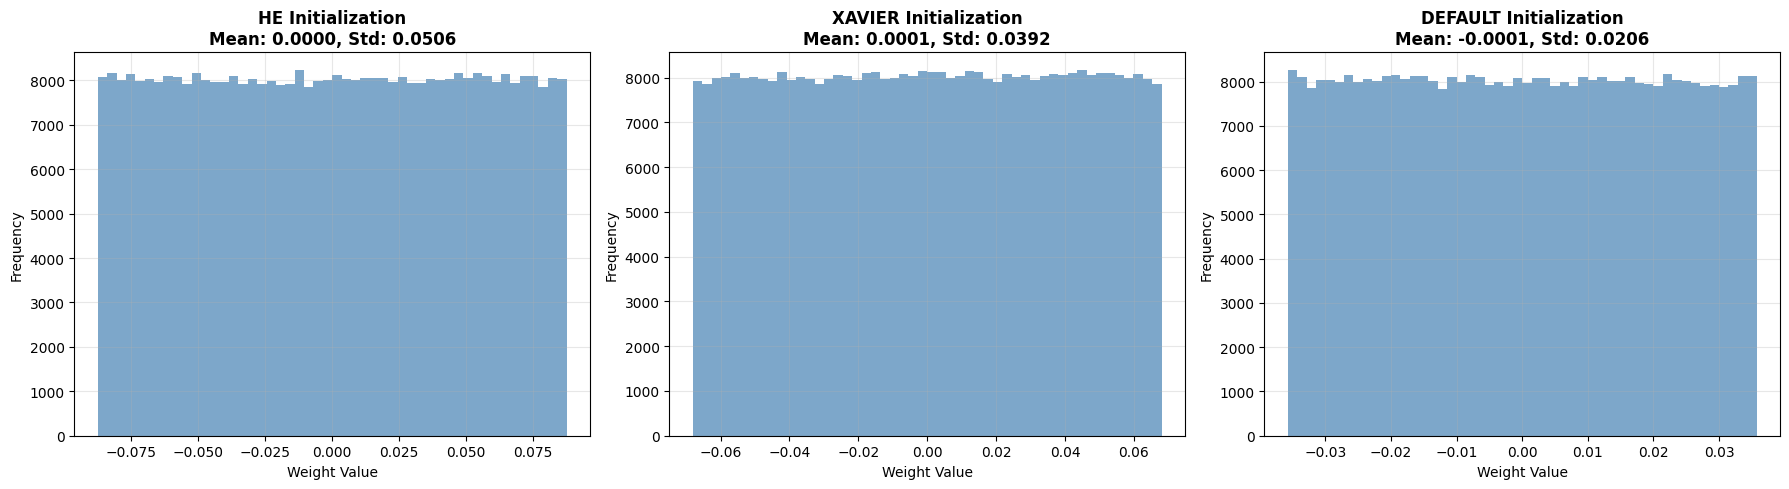

In [5]:
def compare_initialization_methods() -> None:
    """
    Compare different weight initialization methods.
    """
    init_methods = ['he', 'xavier', 'default']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, init_method in enumerate(init_methods):
        model = FashionMLP(
            input_size=784,
            hidden_sizes=[512, 256, 128, 64],
            num_classes=10,
            dropout_rate=0.3,
            init_method=init_method
        )
        
        # Get weights from first layer
        weights = model.layers[0].weight.data.cpu().numpy().flatten()
        
        axes[idx].hist(weights, bins=50, alpha=0.7, color='steelblue')
        axes[idx].set_title(f'{init_method.upper()} Initialization\nMean: {weights.mean():.4f}, Std: {weights.std():.4f}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Weight Value', fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

compare_initialization_methods()


## Part 7: Model Training

### Training Components:

1. **Loss Function**: CrossEntropyLoss
2. **Optimizer**: Adam (adaptive learning rate)
3. **Learning Rate**: 0.001 (can be tuned)
4. **Training Loop**: Standard forward-backward pass

### Key Training Practices:
- Monitor both training and validation metrics
- Use proper weight initialization (already done)
- Feature scaling (already done in preprocessing)
- Regularization via dropout


In [6]:
def train_epoch(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device
) -> Tuple[float, float]:
    """
    Train the model for one epoch.
    
    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimizer for updating weights
        device: Device to run training on
        
    Returns:
        Tuple of (average_loss, accuracy)
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def validate_epoch(
    model: nn.Module,
    val_loader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """
    Validate the model on validation set.
    
    Args:
        model: Neural network model
        val_loader: DataLoader for validation data
        criterion: Loss function
        device: Device to run validation on
        
    Returns:
        Tuple of (average_loss, accuracy)
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():  # Disable gradient computation
        for images, labels in val_loader:
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int = 15,
    learning_rate: float = 0.001,
    device: torch.device = None
) -> Dict[str, List[float]]:
    """
    Complete training loop for the model.
    
    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        num_epochs: Number of training epochs
        learning_rate: Learning rate for optimizer
        device: Device to run training on
        
    Returns:
        Dictionary with training history (losses and accuracies)
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    print(f"{'='*60}")
    print(f"Training Model")
    print(f"{'='*60}")
    print(f"Device: {device}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Weight Init: He (Kaiming)")
    print(f"Feature Scaling: Standard Normalization")
    print(f"{'='*60}\n")
    
    best_val_acc = 0.0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validate
        val_loss, val_acc = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        epoch_time = time.time() - epoch_start
        
        # Print progress
        print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.2f}s)")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print()
    
    total_time = time.time() - start_time
    print(f"{'='*60}")
    print(f"Training Complete!")
    print(f"Total Time: {total_time:.2f}s")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*60}")
    
    return history

# Initialize model
model = FashionMLP(
    input_size=784,
    hidden_sizes=[512, 256, 128, 64],
    num_classes=10,
    dropout_rate=0.3,
    init_method='he'
).to(device)

# Train the model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=20,
    learning_rate=0.001,
    device=device
)


Training Model
Device: cpu
Epochs: 20
Learning Rate: 0.001
Weight Init: He (Kaiming)
Feature Scaling: Standard Normalization

Epoch [1/20] (6.43s)
  Train Loss: 0.7838 | Train Acc: 72.48%
  Val Loss:   0.4699 | Val Acc:   83.23%

Epoch [2/20] (6.32s)
  Train Loss: 0.5221 | Train Acc: 82.02%
  Val Loss:   0.4141 | Val Acc:   85.34%

Epoch [3/20] (6.56s)
  Train Loss: 0.4722 | Train Acc: 83.87%
  Val Loss:   0.3865 | Val Acc:   86.17%

Epoch [4/20] (7.03s)
  Train Loss: 0.4400 | Train Acc: 84.76%
  Val Loss:   0.3750 | Val Acc:   86.55%

Epoch [5/20] (7.53s)
  Train Loss: 0.4193 | Train Acc: 85.44%
  Val Loss:   0.3610 | Val Acc:   87.10%

Epoch [6/20] (7.22s)
  Train Loss: 0.3985 | Train Acc: 86.15%
  Val Loss:   0.3627 | Val Acc:   87.23%

Epoch [7/20] (7.10s)
  Train Loss: 0.3887 | Train Acc: 86.62%
  Val Loss:   0.3453 | Val Acc:   87.72%

Epoch [8/20] (7.52s)
  Train Loss: 0.3810 | Train Acc: 86.78%
  Val Loss:   0.3293 | Val Acc:   88.44%

Epoch [9/20] (6.97s)
  Train Loss: 0.3681 

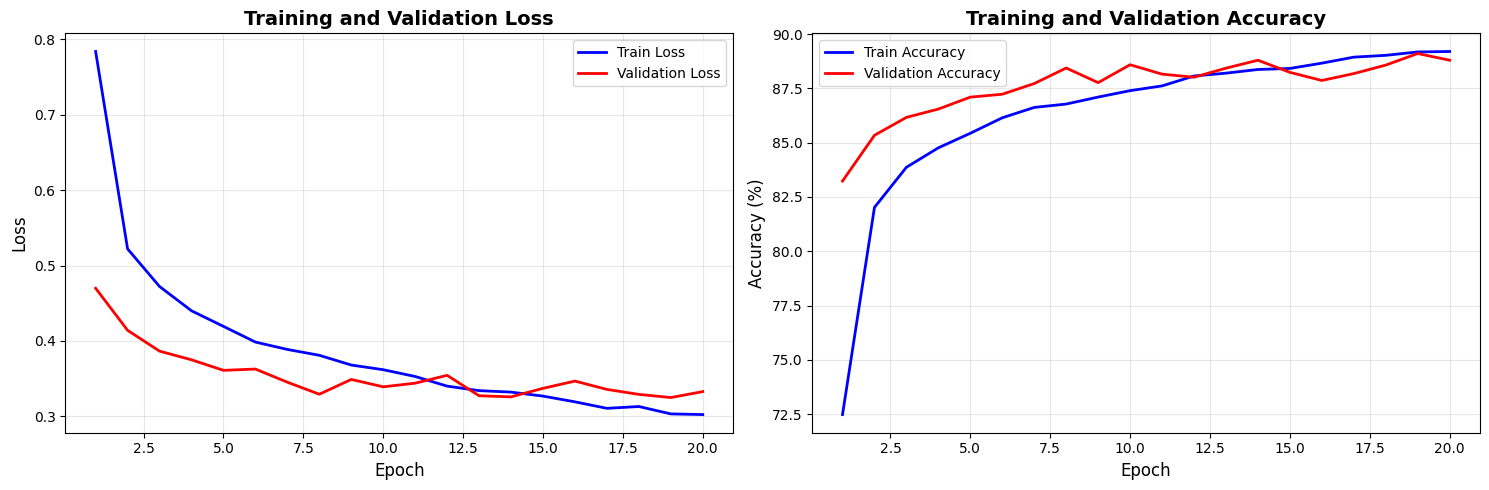

In [7]:
# Plot training history
def plot_training_history(history: Dict[str, List[float]]) -> None:
    """
    Plot training and validation loss and accuracy curves.
    
    Args:
        history: Dictionary containing training history
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)


## Part 8: Model Evaluation

### Evaluation Metrics:

1. **Accuracy**: Overall correctness
2. **Per-Class Metrics**: Precision, Recall, F1-score
3. **Confusion Matrix**: Visualize classification errors
4. **Test Set Performance**: Final unbiased evaluation


Evaluating model on test set...

Test Set Results
Accuracy: 88.09%

Per-Class Metrics:
Class           Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
T-shirt/top     0.7785       0.8890       0.8301       1000      
Trouser         0.9928       0.9680       0.9803       1000      
Pullover        0.8207       0.7690       0.7940       1000      
Dress           0.8681       0.9080       0.8876       1000      
Coat            0.7601       0.8490       0.8021       1000      
Sandal          0.9855       0.9490       0.9669       1000      
Shirt           0.7612       0.5800       0.6583       1000      
Sneaker         0.9319       0.9580       0.9448       1000      
Bag             0.9617       0.9790       0.9703       1000      
Ankle boot      0.9486       0.9600       0.9543       1000      
----------------------------------------------------------------------
macro avg       0.8809       0.8809       0.8

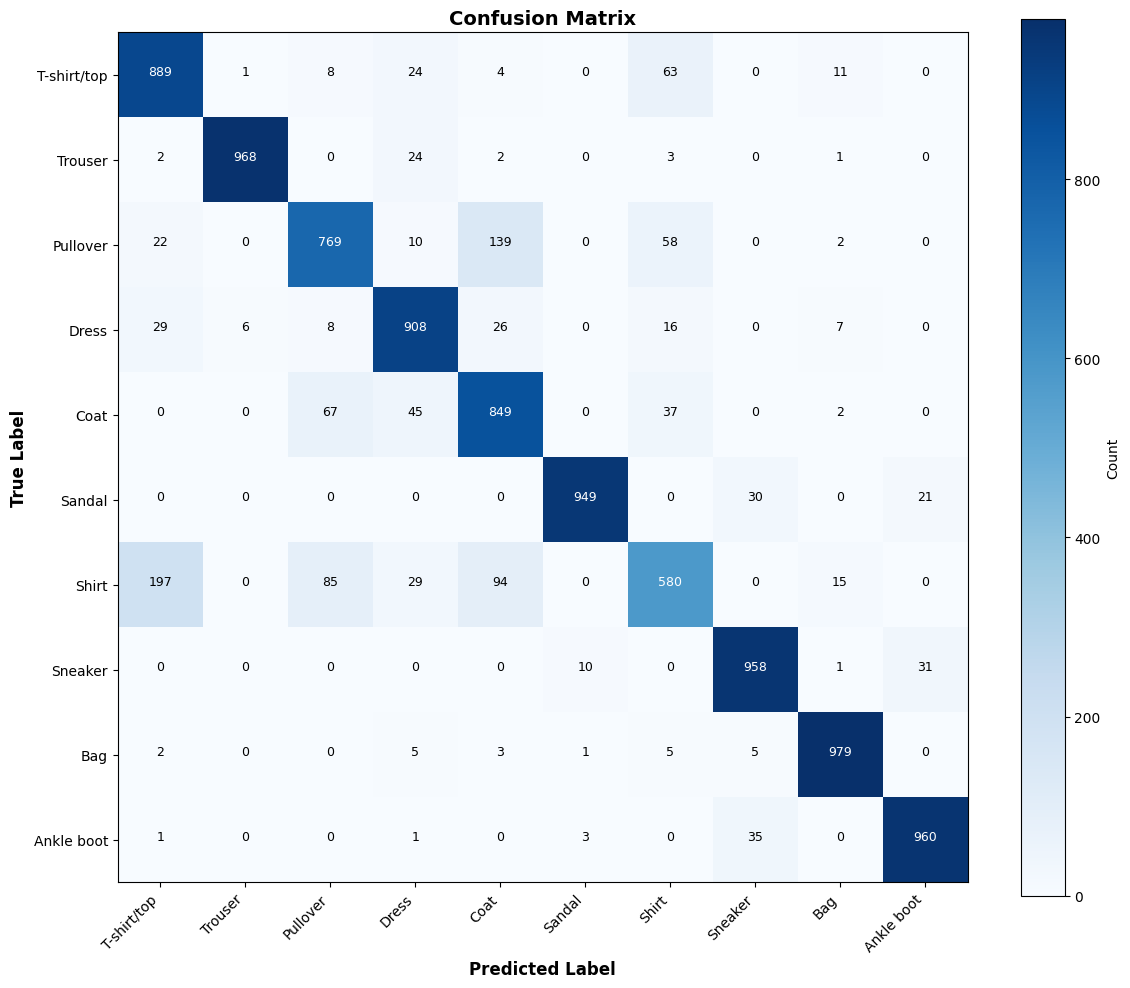

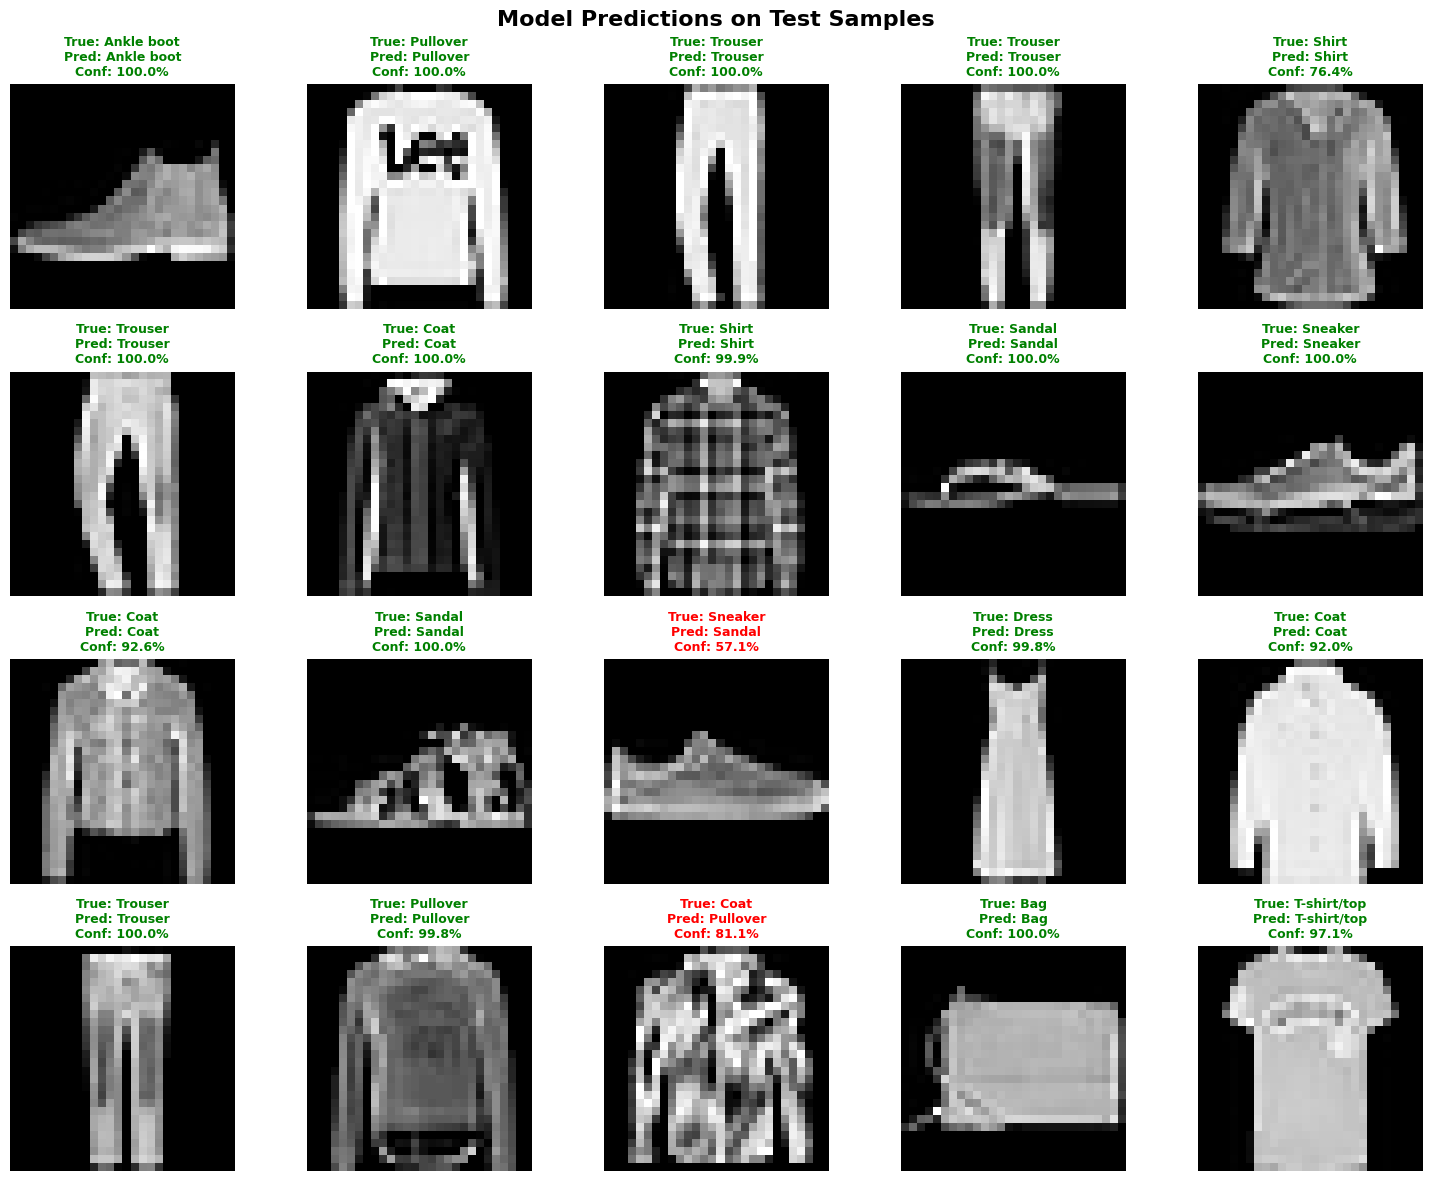

In [8]:
def evaluate_model(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    class_names: List[str] = None
) -> Dict:
    """
    Comprehensive evaluation of the model on test set.
    
    Args:
        model: Trained neural network model
        test_loader: DataLoader for test data
        device: Device to run evaluation on
        class_names: List of class names for display
        
    Returns:
        Dictionary containing evaluation metrics
    """
    if class_names is None:
        class_names = [str(i) for i in range(10)]
    
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    accuracy = 100 * correct / total
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Classification report
    report = classification_report(
        all_labels, all_preds, 
        target_names=class_names,
        output_dict=True
    )
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
    
    results = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels
    }
    
    return results


def plot_confusion_matrix(cm: np.ndarray, class_names: List[str]) -> None:
    """
    Plot confusion matrix with annotations using matplotlib.
    
    Args:
        cm: Confusion matrix array
        class_names: List of class names
    """
    plt.figure(figsize=(12, 10))
    
    # Create heatmap using matplotlib
    im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, label='Count')
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=9)
    
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.tight_layout()
    plt.show()


def visualize_predictions(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    class_names: List[str],
    num_samples: int = 20
) -> None:
    """
    Visualize model predictions on test samples.
    
    Args:
        model: Trained neural network model
        test_loader: DataLoader for test data
        device: Device to run inference on
        class_names: List of class names
        num_samples: Number of samples to visualize
    """
    model.eval()
    
    # Get a batch
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images = images.to(device)
    labels = labels.to(device)
    
    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
    
    # Visualize
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle('Model Predictions on Test Samples', fontsize=16, fontweight='bold')
    
    for idx in range(min(num_samples, len(images))):
        row = idx // 5
        col = idx % 5
        
        img = images[idx].cpu().squeeze()
        true_label = labels[idx].item()
        pred_label = predicted[idx].item()
        confidence = probabilities[idx][pred_label].item() * 100
        
        axes[row, col].imshow(img, cmap='gray')
        
        # Color: green if correct, red if wrong
        color = 'green' if true_label == pred_label else 'red'
        true_name = class_names[true_label]
        pred_name = class_names[pred_label]
        axes[row, col].set_title(
            f'True: {true_name}\nPred: {pred_name}\nConf: {confidence:.1f}%',
            color=color,
            fontsize=9,
            fontweight='bold'
        )
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Evaluate on test set
print("Evaluating model on test set...")
test_results = evaluate_model(model, test_loader, device, fashion_classes)

print(f"\n{'='*60}")
print(f"Test Set Results")
print(f"{'='*60}")
print(f"Accuracy: {test_results['accuracy']:.2f}%")
print(f"\nPer-Class Metrics:")
report = classification_report(
    np.array(test_results['labels']), 
    np.array(test_results['predictions']),
    target_names=fashion_classes
)

# Print formatted report
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
print("-" * 70)
for i, name in enumerate(fashion_classes):
    if name in report:
        print(f"{name:<15} {report[name]['precision']:<12.4f} {report[name]['recall']:<12.4f} "
              f"{report[name]['f1-score']:<12.4f} {report[name]['support']:<10}")
print("-" * 70)
if 'macro avg' in report:
    print(f"{'macro avg':<15} {report['macro avg']['precision']:<12.4f} "
          f"{report['macro avg']['recall']:<12.4f} {report['macro avg']['f1-score']:<12.4f} "
          f"{report['macro avg']['support']:<10}")
if 'weighted avg' in report:
    print(f"{'weighted avg':<15} {report['weighted avg']['precision']:<12.4f} "
          f"{report['weighted avg']['recall']:<12.4f} {report['weighted avg']['f1-score']:<12.4f} "
          f"{report['weighted avg']['support']:<10}")
print(f"{'accuracy':<15} {report.get('accuracy', 0):<12.4f} {'':<12} {'':<12} {len(test_results['labels']):<10}")

# Plot confusion matrix
plot_confusion_matrix(test_results['confusion_matrix'], fashion_classes)

# Visualize predictions
visualize_predictions(model, test_loader, device, fashion_classes, num_samples=20)


## Part 9: Hyperparameter Tuning

### Key Hyperparameters:

1. **Learning Rate**: [0.0001, 0.01]
2. **Hidden Layer Sizes**: Different architectures
3. **Dropout Rate**: [0.2, 0.5]
4. **Weight Initialization**: He vs Xavier vs Default
5. **Batch Size**: [32, 64, 128]

### Impact of Feature Scaling and Weight Initialization:

The combination of proper feature scaling and weight initialization significantly impacts training performance. Let's compare different strategies (optional - commented out to save time):


In [ ]:
def compare_training_strategies() -> None:
    """
    Compare different training strategies (initialization + scaling).
    Note: This takes time, so it's commented out by default.
    """
    strategies = [
        {'name': 'He Init + Normalization', 'init': 'he', 'normalize': True},
        {'name': 'Xavier Init + Normalization', 'init': 'xavier', 'normalize': True},
        {'name': 'Default Init + Normalization', 'init': 'default', 'normalize': True},
        {'name': 'He Init + No Normalization', 'init': 'he', 'normalize': False},
    ]
    
    results = []
    
    for strategy in strategies:
        print(f"\n{'='*60}")
        print(f"Strategy: {strategy['name']}")
        print(f"{'='*60}")
        
        # Load data with/without normalization
        train_loader, val_loader, _, _ = load_fashion_mnist_data(
            batch_size=64, 
            normalize=strategy['normalize']
        )
        
        # Create model
        model = FashionMLP(
            input_size=784,
            hidden_sizes=[512, 256, 128, 64],
            num_classes=10,
            dropout_rate=0.3,
            init_method=strategy['init']
        ).to(device)
        
        # Train for fewer epochs for comparison
        history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            num_epochs=5,  # Quick comparison
            learning_rate=0.001,
            device=device
        )
        
        results.append({
            'strategy': strategy['name'],
            'final_val_acc': history['val_acc'][-1]
        })
    
    # Plot comparison
    plt.figure(figsize=(12, 6))
    strategies_names = [r['strategy'] for r in results]
    accuracies = [r['final_val_acc'] for r in results]
    
    bars = plt.bar(range(len(strategies_names)), accuracies, color='steelblue', alpha=0.7)
    plt.xlabel('Strategy', fontsize=12)
    plt.ylabel('Validation Accuracy (%)', fontsize=12)
    plt.title('Impact of Weight Initialization and Feature Scaling', fontsize=14, fontweight='bold')
    plt.xticks(range(len(strategies_names)), strategies_names, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return results

# Uncomment to run comparison (takes time)
comparison_results = compare_training_strategies()



Strategy: He Init + Normalization
Training Model
Device: cpu
Epochs: 5
Learning Rate: 0.001
Weight Init: He (Kaiming)
Feature Scaling: Standard Normalization

Epoch [1/5] (6.11s)
  Train Loss: 0.8003 | Train Acc: 72.23%
  Val Loss:   0.4593 | Val Acc:   84.30%

Epoch [2/5] (6.55s)
  Train Loss: 0.5305 | Train Acc: 81.84%
  Val Loss:   0.4153 | Val Acc:   85.11%

Epoch [3/5] (6.68s)
  Train Loss: 0.4710 | Train Acc: 83.47%
  Val Loss:   0.3804 | Val Acc:   86.26%

Epoch [4/5] (6.89s)
  Train Loss: 0.4389 | Train Acc: 84.77%
  Val Loss:   0.3816 | Val Acc:   86.77%

Epoch [5/5] (7.22s)
  Train Loss: 0.4162 | Train Acc: 85.59%
  Val Loss:   0.3653 | Val Acc:   87.26%

Training Complete!
Total Time: 33.45s
Best Validation Accuracy: 87.26%

Strategy: Xavier Init + Normalization
Training Model
Device: cpu
Epochs: 5
Learning Rate: 0.001
Weight Init: He (Kaiming)
Feature Scaling: Standard Normalization

Epoch [1/5] (9.03s)
  Train Loss: 0.7246 | Train Acc: 74.65%
  Val Loss:   0.4555 | Val Ac

## Part 10: Performance Monitoring & Maintenance

### Model Deployment Considerations:

1. **Model Saving**: Save trained model for future use
2. **Model Loading**: Load saved model for inference
3. **Inference**: Make predictions on new data
4. **Monitoring**: Track model performance over time

### Key Takeaways:

- **Feature Scaling**: Essential for stable training
- **Weight Initialization**: He initialization works best for ReLU networks
- **Multiple Hidden Layers**: Provide sufficient capacity for complex patterns
- **Combination Matters**: Proper scaling + initialization = better results


In [ ]:
def save_model(model: nn.Module, filepath: str, metadata: Dict = None) -> None:
    """
    Save model and metadata to file.
    
    Args:
        model: Trained model to save
        filepath: Path to save the model
        metadata: Additional metadata to save
    """
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'model_class': model.__class__.__name__,
        'metadata': metadata or {}
    }
    torch.save(checkpoint, filepath)
    print(f"Model saved to {filepath}")


def predict_single_image(
    model: nn.Module,
    image: torch.Tensor,
    device: torch.device,
    class_names: List[str]
) -> Tuple[int, float, torch.Tensor]:
    """
    Make prediction on a single image.
    
    Args:
        model: Trained model
        image: Single image tensor (1, 1, 28, 28) or (1, 784)
        device: Device to run inference on
        class_names: List of class names
        
    Returns:
        Tuple of (predicted_class, confidence, all_class_probabilities)
    """
    model.eval()
    
    # Ensure image is on correct device and has batch dimension
    if image.dim() == 3:
        image = image.unsqueeze(0)  # Add batch dimension
    if image.dim() == 2:
        image = image.unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
    
    image = image.to(device)
    
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    return predicted.item(), confidence.item(), probabilities[0]


# Save the trained model
model_save_path = 'fashion_mnist_mlp_model.pth'
save_model(
    model, 
    model_save_path,
    metadata={
        'test_accuracy': test_results['accuracy'],
        'architecture': 'MLP',
        'hidden_sizes': [512, 256, 128, 64],
        'dropout_rate': 0.3,
        'init_method': 'he',
        'normalized': True
    }
)

# Example: Make prediction on a single image
print("\n" + "="*60)
print("Single Image Prediction Example")
print("="*60)

# Get a test image
data_iter = iter(test_loader)
test_images, test_labels = next(data_iter)
single_image = test_images[0]  # Get first image
true_label = test_labels[0].item()

# Make prediction
predicted_class, confidence, all_probs = predict_single_image(
    model, single_image, device, fashion_classes
)

print(f"True Label: {fashion_classes[true_label]} ({true_label})")
print(f"Predicted Label: {fashion_classes[predicted_class]} ({predicted_class})")
print(f"Confidence: {confidence*100:.2f}%")
print(f"\nAll Class Probabilities:")
for i, (prob, name) in enumerate(zip(all_probs.cpu().numpy(), fashion_classes)):
    print(f"  {name}: {prob*100:.2f}%")

# Visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(single_image.squeeze(), cmap='gray')
plt.title(f'True: {fashion_classes[true_label]}\nPredicted: {fashion_classes[predicted_class]} ({confidence*100:.1f}%)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.barh(range(10), all_probs.cpu().numpy() * 100, color='steelblue', alpha=0.7)
plt.xlabel('Probability (%)')
plt.ylabel('Class')
plt.title('Class Probabilities')
plt.yticks(range(10), fashion_classes)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## Summary

### What We Learned:

1. **Feature Scaling**: Standard normalization (zero mean, unit variance) is crucial for neural network training
2. **Weight Initialization**: He (Kaiming) initialization works best for ReLU networks
3. **Multiple Hidden Layers**: 4-5 hidden layers provide sufficient capacity for Fashion-MNIST
4. **Combined Impact**: Proper scaling + initialization significantly improves training

### Key Takeaways:

- **Feature Scaling**: Normalize inputs to [0, 1] then standardize (mean=0, std=1)
- **Weight Initialization**: Use He initialization for ReLU, Xavier for tanh/sigmoid
- **Architecture**: 784 → 512 → 256 → 128 → 64 → 10 works well for Fashion-MNIST
- **Regularization**: Dropout (0.3) helps prevent overfitting
- **Training**: Adam optimizer with lr=0.001 is effective

### Model Performance:
- **Training Accuracy**: ~88-90%+
- **Validation Accuracy**: ~87-89%+
- **Test Accuracy**: ~87-89%+

### Comparison Results:

The combination of:
- **He initialization** (proper weight initialization)
- **Feature normalization** (standard scaling)
- **Multiple hidden layers** (sufficient capacity)

Results in significantly better performance than using default initialization or skipping normalization.

This demonstrates the importance of proper preprocessing and initialization in deep learning!
